# YOLO Lane Detection Pipeline

### Pipeline Overview
```
Front Camera
    │
    └─► YOLO segmentation  →  build_lane_masks()  →  binary mask
                                                           ↓
                                                     fit_lane()
                                                           ↓
                                                    detect_lanes()  →  center_norm
                                                           ↓
                                           Pure Pursuit Controller → CARLA Steer
```

**Detection classes:** `left_marking` (class 0) · `right_edge` (class 1)  
**Weather conditions:** Clear · Fog · Night · Rain


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

/home/peeradon/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1 · Load Model & Images


In [5]:
WEIGHTS = '/home/peeradon/lka-carla-yolo/models/best_vision.pt'
IMAGES  = {
    'clear': '/home/peeradon/lka-carla-yolo/Images/clear.png',
    'fog':   '/home/peeradon/lka-carla-yolo/Images/fog.png',
    'night': '/home/peeradon/lka-carla-yolo/Images/night.png',
    'rain':  '/home/peeradon/lka-carla-yolo/Images/rain.png',
}

# ── Parameters (same as lane_detection_params.yaml) ──────────
MIN_DET_CONF = 0.45
POLY_DEGREE  = 1
MIN_PIXELS   = 50
Y_TOP_RATIO  = 0.50
Y_REF_RATIO  = 0.85

model = YOLO(WEIGHTS)
print('Model loaded:', WEIGHTS)

Model loaded: /home/peeradon/lka-carla-yolo/models/best_vision.pt


## 2 · YOLO Raw Polygon Output

Change `WEATHER` to test each condition.


Image: /home/peeradon/lka-carla-yolo/Images/rain.png  ->  1600x900 px
Detections: 3
  [0] class=right_edge       conf=0.990  polygon_points=203
  [1] class=left_marking     conf=0.958  polygon_points=46
  [2] class=left_marking     conf=0.918  polygon_points=7


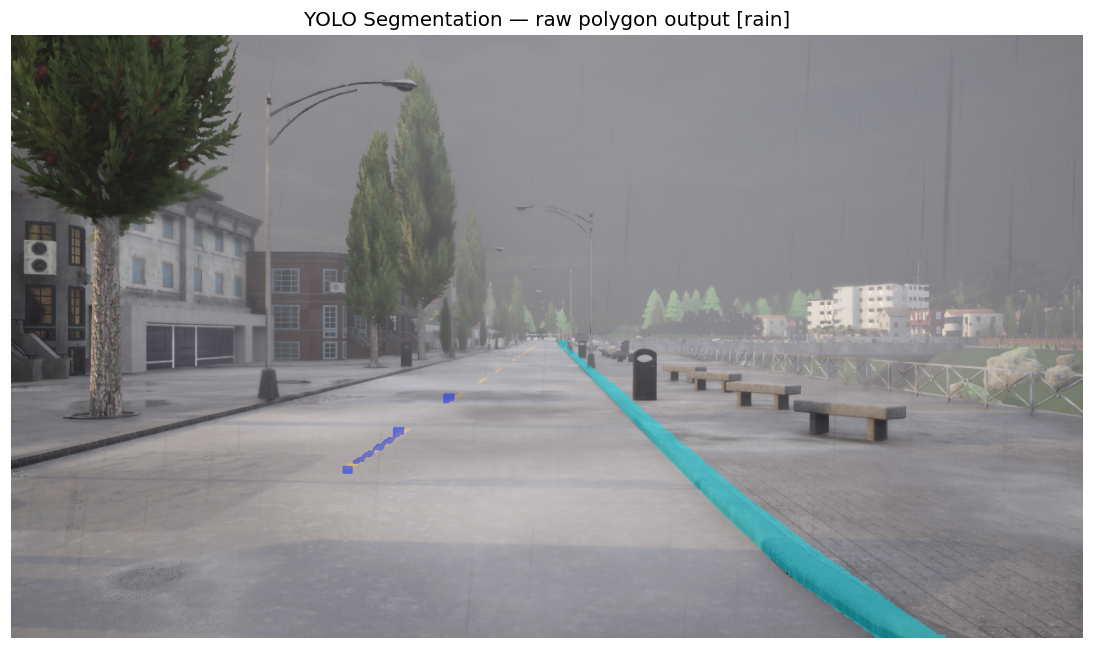

In [6]:
# ── ▼ Change this ▼ ───────────────────────────────────────────
WEATHER = 'rain'   # 'clear' | 'fog' | 'night' | 'rain'
# ──────────────────────────────────────────────────────────────

img_bgr = cv2.imread(IMAGES[WEATHER])
H, W    = img_bgr.shape[:2]
print(f'Image: {IMAGES[WEATHER]}  ->  {W}x{H} px')

results = model.predict(img_bgr, conf=MIN_DET_CONF, device=0, verbose=False)[0]
print(f'Detections: {len(results.boxes)}')

if results.masks is not None:
    for i, (poly, cls, conf) in enumerate(zip(
            results.masks.xy,
            results.boxes.cls.cpu().numpy().astype(int),
            results.boxes.conf.cpu().numpy())):
        print(f'  [{i}] class={results.names[cls]:15s}  conf={conf:.3f}  polygon_points={len(poly)}')
else:
    print('  No masks detected')

annotated = results.plot(boxes=False, labels=False, conf=False)
plt.figure(figsize=(14, 6))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title(f'YOLO Segmentation — raw polygon output [{WEATHER}]', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()

## 3 · `build_lane_masks` — Polygon → Binary Mask

YOLO returns **polygon corner points**. We rasterize them into a **binary mask**
to identify which pixels belong to each lane line.

```
polygon points  →  cv2.fillPoly()  →  mask (0/255 per pixel)
```

- `left_mask`  = pixels of the left marking (class 0)
- `right_mask` = pixels of the right edge (class 1)


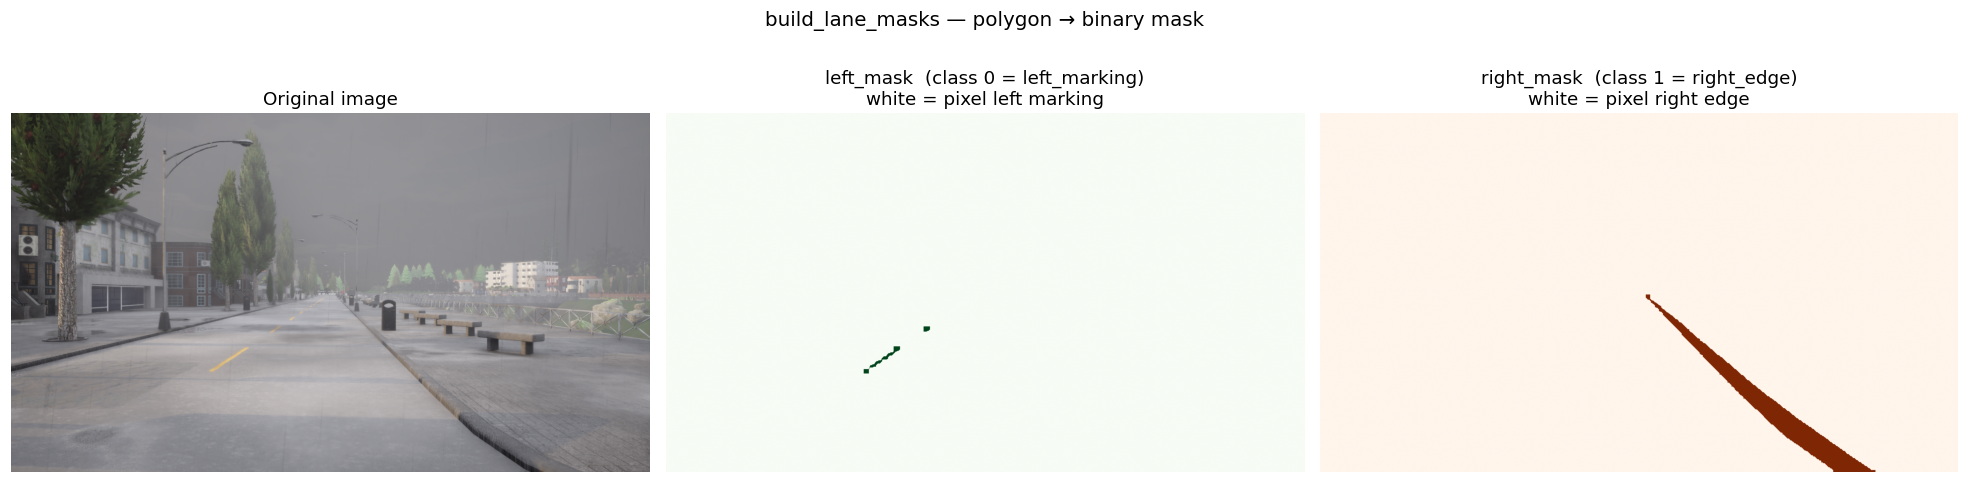

left_mask  : 993 white pixels
right_mask : 25788 white pixels


In [7]:
def build_lane_masks(results, h, w):
    """Rasterize YOLO polygons into left/right binary masks."""
    left_mask  = np.zeros((h, w), dtype=np.uint8)
    right_mask = np.zeros((h, w), dtype=np.uint8)

    for poly, conf, cls in zip(results.masks.xy,
                               results.boxes.conf.cpu().numpy(),
                               results.boxes.cls.cpu().numpy().astype(int)):
        if len(poly) < 3 or conf < MIN_DET_CONF:
            continue
        pts = poly.astype(np.int32)
        if cls == 0:
            cv2.fillPoly(left_mask, [pts], 255)
        else:
            cv2.fillPoly(right_mask, [pts], 255)

    return left_mask, right_mask


left_mask, right_mask = build_lane_masks(results, H, W)

# แสดงผล
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('build_lane_masks — polygon → binary mask', fontsize=13)

axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original image')
axes[0].axis('off')

axes[1].imshow(left_mask, cmap='Greens')
axes[1].set_title('left_mask  (class 0 = left_marking)\nwhite = pixel left marking')
axes[1].axis('off')

axes[2].imshow(right_mask, cmap='Oranges')
axes[2].set_title('right_mask  (class 1 = right_edge)\nwhite = pixel right edge')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f'left_mask  : {(left_mask  > 0).sum()} white pixels')
print(f'right_mask : {(right_mask > 0).sum()} white pixels')

## 4 · `fit_lane` — Mask Pixels → Polynomial Line

Extract white pixels from the mask and fit a line **x = f(y)** using `np.polyfit`.

```
np.where(mask > 0)  →  (ys, xs)  all pixel coordinates
np.polyfit(ys, xs, degree)  →  coefficients
np.polyval(coeffs, y_ref)   →  x at row y_ref
```

Why fit `x = f(y)` instead of `y = f(x)`?  
Lane lines are nearly vertical — a single y cannot have multiple x values → axes must be swapped.


In [ ]:
# ── draw_lane_line — copied from yolo_node.py (used in all cells below) ───────
def draw_lane_line(img, fit, color, label, label_offset_x):
    h, w = img.shape[:2]
    coeffs, y_top, _ = fit
    ys = np.linspace(y_top, h - 1, 60).astype(int)
    xs = np.polyval(coeffs, ys).astype(int)
    for i in range(len(ys) - 1):
        if 0 <= xs[i] < w and 0 <= xs[i + 1] < w:
            cv2.line(img, (xs[i], ys[i]), (xs[i + 1], ys[i + 1]), color, 3)
    label_x = max(0, int(xs[-1]) + label_offset_x)
    cv2.putText(img, label, (label_x, h - 20), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)


def fit_lane(mask, roi_top, roi_bot):
    """Fit polynomial x=f(y) through mask pixels in [roi_top, roi_bot].
    Returns (coeffs, y_top, y_bot) or None when too few pixels."""
    ys, xs = np.where(mask[roi_top:roi_bot] > 0)
    if len(xs) < MIN_PIXELS:
        return None
    ys_abs = ys + roi_top
    coeffs = np.polyfit(ys_abs, xs, POLY_DEGREE)
    return coeffs, int(ys_abs.min()), int(ys_abs.max())


roi_top = int(H * Y_TOP_RATIO)
y_ref   = int(H * Y_REF_RATIO)

left_fit  = fit_lane(left_mask,  roi_top, H - 1)
right_fit = fit_lane(right_mask, roi_top, H - 1)

print(f'ROI: y={roi_top}..{H-1}  |  y_ref={y_ref}')
print(f'left_fit  : {"coeffs=" + str(np.round(left_fit[0],3))  if left_fit  else "None (too few pixels)"}')
print(f'right_fit : {"coeffs=" + str(np.round(right_fit[0],3)) if right_fit else "None (too few pixels)"}')

# ── 3-panel visualization ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle('fit_lane — polyfit x=f(y) through mask pixels', fontsize=13)

for ax, (show_left, show_right, title) in zip(axes, [
    (True,  False, 'Left fit only'),
    (False, True,  'Right fit only'),
    (True,  True,  'Both + circles'),
]):
    v = img_bgr.copy()

    if show_left and show_right:
        overlay = v.copy()
        cv2.rectangle(overlay, (0, 0), (W, roi_top), (0, 0, 0), -1)
        cv2.addWeighted(overlay, 0.5, v, 0.5, 0, v)
        cv2.line(v, (0, roi_top), (W, roi_top), (255, 0, 255), 3)
        cv2.putText(v, f'Y_TOP_RATIO={Y_TOP_RATIO}  (y={roi_top})  ROI start',
                    (10, roi_top - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 0, 255), 2)
        cv2.line(v, (0, y_ref), (W, y_ref), (0, 255, 255), 3)
        cv2.putText(v, f'Y_REF_RATIO={Y_REF_RATIO}  (y={y_ref})  measure center here',
                    (10, y_ref - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 255, 255), 2)

    # draw_lane_line with common_y_top when both sides shown
    if show_left and show_right and left_fit is not None and right_fit is not None:
        common_y_top = max(left_fit[1], right_fit[1])
        draw_lane_line(v, (left_fit[0],  common_y_top, left_fit[2]),  (0, 255, 0),   'left_marking',  10)
        draw_lane_line(v, (right_fit[0], common_y_top, right_fit[2]), (0, 255, 255), 'right_edge',  -160)
        lx = int(np.polyval(left_fit[0],  y_ref))
        rx = int(np.polyval(right_fit[0], y_ref))
        cx = (lx + rx) // 2
        cv2.circle(v, (lx, y_ref), 10, (0, 255, 0),   -1)
        cv2.circle(v, (rx, y_ref), 10, (0, 255, 255),  -1)
        cv2.circle(v, (cx, y_ref), 14, (0, 0, 255),    -1)
        cv2.line(v, (W // 2, y_ref - 25), (W // 2, y_ref + 25), (255, 255, 0), 2)
        cv2.arrowedLine(v, (W // 2, y_ref), (cx, y_ref), (0, 255, 255), 2, tipLength=0.2)
        cv2.putText(v, f'lx={lx}', (lx+5, y_ref-15), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0),   2)
        cv2.putText(v, f'rx={rx}', (rx+5, y_ref-15), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255),  2)
        cv2.putText(v, f'cx={cx} -> {cx/W:.3f}', (cx+5, y_ref+25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    else:
        if show_left  and left_fit  is not None:
            draw_lane_line(v, left_fit,  (0, 255, 0),   'left_marking',  10)
        if show_right and right_fit is not None:
            draw_lane_line(v, right_fit, (0, 255, 255), 'right_edge',  -160)

    ax.imshow(cv2.cvtColor(v, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 5 · `detect_lanes` — Full Pipeline

Combines `build_lane_masks` + `fit_lane` to compute `center_norm`.

```
lx = polyval(left_coeffs,  y_ref)   # x of left line at row y_ref
rx = polyval(right_coeffs, y_ref)   # x of right line at row y_ref
center_px   = (lx + rx) / 2
center_norm = center_px / W         # publish to /lka/lane_center
```

If only one side is detected → `detected = False` → controller brakes.


In [9]:
def detect_lanes(results, h, w):
    """Returns (center_px, mean_conf, left_fit, right_fit)."""
    if results.masks is None or len(results.boxes) == 0:
        return None, 0.0, None, None

    left_mask, right_mask = build_lane_masks(results, h, w)

    roi_top = int(h * Y_TOP_RATIO)
    y_ref   = int(h * Y_REF_RATIO)

    left_fit  = fit_lane(left_mask,  roi_top, h - 1)
    right_fit = fit_lane(right_mask, roi_top, h - 1)

    if left_fit is None or right_fit is None:
        return None, 0.0, left_fit, right_fit

    lx = np.polyval(left_fit[0],  y_ref)
    rx = np.polyval(right_fit[0], y_ref)
    center_px = (lx + rx) / 2.0
    mean_conf = float(results.boxes.conf.cpu().numpy().mean())

    return center_px, mean_conf, left_fit, right_fit


center_px, mean_conf, left_fit, right_fit = detect_lanes(results, H, W)

if center_px is not None:
    center_norm  = center_px / W
    lateral_err  = center_px - (W / 2)
    lx = np.polyval(left_fit[0],  int(H * Y_REF_RATIO))
    rx = np.polyval(right_fit[0], int(H * Y_REF_RATIO))
    print(f'[{WEATHER}]')
    print(f'  lx (left  @ y_ref) = {lx:.1f} px  ->  {lx/W:.3f}')
    print(f'  rx (right @ y_ref) = {rx:.1f} px  ->  {rx/W:.3f}')
    print(f'  center_px          = (lx + rx) / 2 = {center_px:.1f} px')
    print(f'  center_norm        = {center_px:.1f} / {W} = {center_norm:.3f}  → publish /lka/lane_center')
    print(f'  lateral_error      = center - image_center = {lateral_err:+.1f} px')
    print(f'  mean_conf          = {mean_conf:.3f}')
    print(f'  detected           = True')
else:
    print('NO DETECTION — detected = False → controller will brake')

[rain]
  lx (left  @ y_ref) = 333.1 px  ->  0.208
  rx (right @ y_ref) = 1165.1 px  ->  0.728
  center_px          = (lx + rx) / 2 = 749.1 px
  center_norm        = 749.1 / 1600 = 0.468  → publish /lka/lane_center
  lateral_error      = center - image_center = -50.9 px
  mean_conf          = 0.955
  detected           = True


## 6 · Center Normalization


In [ ]:
if center_px is None:
    print('No detection to plot')
else:
    y_ref  = int(H * Y_REF_RATIO)
    lx_val = int(np.polyval(left_fit[0],  y_ref))
    rx_val = int(np.polyval(right_fit[0], y_ref))
    cx_val = int(center_px)
    cn_val = center_px / W
    img_cx = W // 2

    # ── Build annotated image — same as draw_debug in yolo_node.py ────────────
    vis2 = img_bgr.copy()

    # common_y_top + draw_lane_line (same as node)
    common_y_top = max(left_fit[1], right_fit[1])
    draw_lane_line(vis2, (left_fit[0],  common_y_top, left_fit[2]),  (0, 255, 0),   'left_marking',  10)
    draw_lane_line(vis2, (right_fit[0], common_y_top, right_fit[2]), (0, 255, 255), 'right_edge',  -160)

    cv2.circle(vis2, (cx_val, y_ref), 10, (0, 0, 255), -1)
    cv2.line(vis2, (img_cx, y_ref - 25), (img_cx, y_ref + 25), (255, 255, 0), 2)
    cv2.arrowedLine(vis2, (img_cx, y_ref), (cx_val, y_ref), (0, 255, 255), 2, tipLength=0.2)
    cv2.putText(vis2, f'YOLO   center: {cn_val:.3f}', (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    real_error = cn_val - 0.5
    err_color  = (0, 255, 0) if abs(cx_val - img_cx) < 50 else (0, 0, 255)
    cv2.putText(vis2, f'err:    {real_error:+.3f}  (no GT)', (10, 54), cv2.FONT_HERSHEY_SIMPLEX, 0.7, err_color, 2)

    # ── Plot with axvline legend ───────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.suptitle('center_norm = cx / W', fontsize=14, fontweight='bold')

    ax.imshow(cv2.cvtColor(vis2, cv2.COLOR_BGR2RGB))
    for xv, col, ls, lw, lbl in [
        (lx_val, 'tab:green',  '-',  2.0, f'lx = {lx_val} px  ({lx_val/W:.3f})'),
        (rx_val, 'tab:orange', '-',  2.0, f'rx = {rx_val} px  ({rx_val/W:.3f})'),
        (cx_val, 'tab:red',    '-',  2.5, f'cx = (lx+rx)/2 = {cx_val} px  →  {cn_val:.3f}'),
        (img_cx, 'tab:cyan',   '--', 1.5, f'image center = {img_cx} px  (= 0.500)'),
    ]:
        ax.axvline(xv, color=col, lw=lw, linestyle=ls, label=lbl)

    ax.set_title(f'YOLO   center_norm = {cn_val:.3f}  [{WEATHER}]')
    ax.legend(loc='upper left', fontsize=9, framealpha=0.85)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    print(f'lx={lx_val}  rx={rx_val}  cx={cx_val}  W={W}')
    print(f'center_norm = {cx_val}/{W} = {cn_val:.4f}')

## 7 · All 4 Weather Conditions


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(22, 14))
fig.suptitle('detect_lanes — All 4 Weather Conditions', fontsize=14, fontweight='bold')

summary = []

for ax, weather in zip(axes.flat, ['clear', 'fog', 'night', 'rain']):
    img  = cv2.imread(IMAGES[weather])
    h, w = img.shape[:2]
    yr   = int(h * Y_REF_RATIO)
    img_cx = w // 2

    res  = model.predict(img, conf=MIN_DET_CONF, device=0, verbose=False)[0]
    cx_r, mc, lf, rf = detect_lanes(res, h, w)

    # Start from annotated (YOLO polygon overlay) — same as node which uses results.plot()
    vis = res.plot()

    # draw_lane_line + common_y_top (same as draw_debug in yolo_node.py)
    if lf is not None and rf is not None:
        common_y_top = max(lf[1], rf[1])
        draw_lane_line(vis, (lf[0], common_y_top, lf[2]), (0, 255, 0),   'left_marking',  10)
        draw_lane_line(vis, (rf[0], common_y_top, rf[2]), (0, 255, 255), 'right_edge',  -160)
    else:
        if lf is not None: draw_lane_line(vis, lf, (0, 255, 0),   'left_marking',  10)
        if rf is not None: draw_lane_line(vis, rf, (0, 255, 255), 'right_edge',  -160)

    if cx_r is None:
        # NO DETECTION banner (same as draw_debug)
        overlay = vis.copy()
        cv2.rectangle(overlay, (0, 0), (w, 95), (0, 0, 180), -1)
        cv2.addWeighted(overlay, 0.45, vis, 0.55, 0, vis)
        cv2.putText(vis, '!! NO DETECTION !!', (10, 32), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)
        cv2.putText(vis, f'conf: {mc:.3f}', (10, 58), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 165, 255), 2)
        summary.append((weather, None, None, 0.0, 0))
    else:
        cn  = cx_r / w
        err = cx_r - (w / 2)
        cx_i = int(cx_r)

        cv2.circle(vis, (cx_i, yr), 10, (0, 0, 255), -1)
        cv2.line(vis, (img_cx, yr - 25), (img_cx, yr + 25), (255, 255, 0), 2)
        cv2.arrowedLine(vis, (img_cx, yr), (cx_i, yr), (0, 255, 255), 2, tipLength=0.2)
        cv2.putText(vis, f'YOLO   center: {cn:.3f}', (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        real_error = cn - 0.5
        err_color  = (0, 255, 0) if abs(cx_i - img_cx) < 50 else (0, 0, 255)
        cv2.putText(vis, f'err:    {real_error:+.3f}  (no GT)', (10, 54), cv2.FONT_HERSHEY_SIMPLEX, 0.7, err_color, 2)
        cv2.putText(vis, f'conf:   {mc:.3f}', (10, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
        summary.append((weather, cn, err, mc, len(res.boxes)))

    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(weather.upper(), fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

print('\n-- Summary --------------------------------------------------')
print(f'{"Weather":8s}  {"center":>8s}  {"err(px)":>9s}  {"conf":>6s}  {"det":>4s}')
for weather, cn, err, mc, *rest in summary:
    n     = rest[0] if rest else 0
    cn_s  = f'{cn:.3f}'   if cn  is not None else 'MISS'
    err_s = f'{err:+.0f}' if err is not None else 'MISS'
    print(f'{weather:8s}  {cn_s:>8s}  {err_s:>9s}  {mc:>6.3f}  {n:>4d}')